____
# Spatial scales

# ATTENTION : change mid-height cutoff by half-power cutoff

mid-height cutoff * 2$\pi$ = half-power cutoff

In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import (
    swot_dir,
    drifters_dir,
    get_proj,
    lonlat2xy,
    zarr_dir,
    surface_drifters,
    depth_drifters,
    depth_100,
    depth_50,
    images_dir,
    U2,
    err_acc,
)
from diagnosis import (
    put_fig_letter,
    update_dict,
    dataset_coloc_combs,
    dataset_coloc_combs,
    prepared_drifters,
    prepared_wd,
    prepared_alti,
    compute_variance,
    compute_variance_groupby,
    plot_error,
)

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo

crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [2]:
dt = 3
distance_to_coast_max = 20e3
alti_product_key = "swot2km"
drifter_preprocess = ""
drifter_preprocess_param = ""
max_ggd = 1e-4
from diagnosis import define_coloc_source

colocs_sources = define_coloc_source(
    "12h", drifter_preprocess, drifter_preprocess_param
)

_______
# Gaussian

In [3]:
cutoff = sorted(list(np.arange(5e3,51e3, 10e3))+list(np.arange(1e3,10e3, 1e3)) + list(np.arange(10e3,50e3, 10e3))+list(np.arange(50e3, 301e3, 30e3)))
cutoff

[1000.0,
 2000.0,
 3000.0,
 4000.0,
 5000.0,
 5000.0,
 6000.0,
 7000.0,
 8000.0,
 9000.0,
 10000.0,
 15000.0,
 20000.0,
 25000.0,
 30000.0,
 35000.0,
 40000.0,
 45000.0,
 50000.0,
 80000.0,
 110000.0,
 140000.0,
 170000.0,
 200000.0,
 230000.0,
 260000.0,
 290000.0]

In [8]:
# GAUSSIAN
#cutoff = list(np.arange(4e3, 20e3, 2e3)) + list(np.arange(20e3, 60e3, 5e3))
#cutoff = list(np.arange(5e3,31e3, 5e3))+list(np.arange(40e3, 301e3, 20e3))
# SURFACE
base_dic = dict(
    dt="12h",
    drifter_preprocess=drifter_preprocess,
    drifter_preprocess_param=drifter_preprocess_param,
    alti_product_key=alti_product_key,
    alti_diff_method="gaussian_aviso",
    alti_diff_method_param="",
    ggd_var="etaf",
    wd_product_key="era5",
    wd_model="rio",
    wd_depth="0",
)

comb_list = [
    update_dict(base_dic, dict(alti_diff_method_param=int(ct))) for ct in cutoff
]

ds0 = dataset_coloc_combs(comb_list, nearest=False, remove_id_outliers=True)
ds0["comb"] = ds0["id_comb"]
ds0["id_comb"] = ("id_comb", cutoff)
distance_to_coast = ds0.distance_to_coast.isel(id_comb=0)
ds0["distance_to_coast"] = ("row_number", distance_to_coast.values)

ds0 = ds0.where(
    (ds0.drifter_type != "SPOTTER") & (ds0.drifter_type != "MELODI"), drop=True
)

# DEPTH 15M
base_dic = update_dict(base_dic, dict(wd_depth="15"))
comb_list = [
    update_dict(base_dic, dict(alti_diff_method_param=int(ct))) for ct in cutoff
]

ds15 = dataset_coloc_combs(comb_list, nearest=False, remove_id_outliers=True)
ds15["comb"] = ds15["id_comb"]
ds15["id_comb"] = ("id_comb", cutoff)
distance_to_coast = ds15.distance_to_coast.isel(id_comb=0)
ds15["distance_to_coast"] = ("row_number", distance_to_coast.values)

DS = xr.concat(
    [ds0.where(ds0.depth == 0, drop=True), ds15.where(ds15.depth == 15, drop=True)],
    dim="row_number",
)
DS = DS.where(DS.time_to_swot / pd.Timedelta("1h") < dt).dropna("row_number")
# DS = DS.where((abs(DS.ggde)<max_ggd) & (abs(DS.ggdn)<max_ggd), drop=True)
DSG = DS.where(DS.distance_to_coast > distance_to_coast_max, drop=True)

# Closure figs
dsg = compute_variance(DSG, compute_error="centrallimit") / U2

DSG = DSG.rename({"id_comb": "cutoff"})
DSG["cutoff"] = DSG.cutoff / 1000
DSG["cutoff"] = DSG["cutoff"].assign_attrs(
    {"long_name": "Gaussian filter cutoff", "units": "km"}
)
dsg = dsg.rename({"id_comb": "cutoff"})
dsg["cutoff"] = dsg.cutoff / 1000
dsg["cutoff"] = dsg["cutoff"].assign_attrs(
    {"long_name": "Gaussian filter cutoff", "units": "km"}
)

12h_spectral_decomp_all_med_variational_10min_v1____swot2km_gaussian_aviso_1000_etaf__era5_rio0
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_gaussian_aviso_2000_etaf__era5_rio0
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_gaussian_aviso_3000_etaf__era5_rio0
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_gaussian_aviso_4000_etaf__era5_rio0
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_gaussian_aviso_5000_etaf__era5_rio0
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_gaussian_aviso_5000_etaf__era5_rio0
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_gaussian_aviso_6000_etaf__era5_rio0
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_gaussian_aviso_7000_etaf__era5_rio0
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_gaussian_aviso_8000_etaf__era5_rio0
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_gaussian_aviso_9000_etaf__era5_rio0
12h_spectral_decomp_all_med_variational_

In [9]:
dsg.to_netcdf(
    os.path.join(
        zarr_dir, "diag_files", f"gaussian_aviso_{colocs_sources}_filtered_nospotter.nc"
    )
)

In [7]:
dsg.to_netcdf(
    os.path.join(
        zarr_dir,
        "diag_files",
        f"gaussian_aviso_{colocs_sources}_calibrated_nospotter.nc",
    )
)

## If already computed

In [4]:
xlim =200
dsgf = xr.open_dataset(
    os.path.join(
        zarr_dir, "diag_files", f"gaussian_aviso_{colocs_sources}_filtered_nospotter.nc"
    )
).sel(cutoff=slice(10,xlim))
dsgc = xr.open_dataset(
    os.path.join(
        zarr_dir,
        "diag_files",
        f"gaussian_aviso_{colocs_sources}_calibrated_nospotter.nc",
    )
).sel(cutoff=slice(10,xlim))

In [5]:
# No filter point

# SURFACE
base_dic = dict(
    dt="12h",
    drifter_preprocess=drifter_preprocess,
    drifter_preprocess_param=drifter_preprocess_param,
    alti_product_key=alti_product_key,
    alti_diff_method="xarray_diff",
    alti_diff_method_param="",
    ggd_var="etaf",
    wd_product_key="era5",
    wd_model="rio",
    wd_depth="0",
)
comb_list = [base_dic, update_dict(base_dic, {"ggd_var": "etac"})]
ds0 = dataset_coloc_combs(comb_list, nearest=False, remove_id_outliers=True)
ds0["comb"] = ds0["id_comb"]
ds0["id_comb"] = ("id_comb", ["filtered", "calibrated"])
distance_to_coast = ds0.distance_to_coast.isel(id_comb=0)
ds0["distance_to_coast"] = ("row_number", distance_to_coast.values)

ds0 = ds0.where(
    (ds0.drifter_type != "SPOTTER") & (ds0.drifter_type != "MELODI"), drop=True
)

# DEPTH 15M
comb_list = [update_dict(c, dict(wd_depth="15")) for c in comb_list]

ds15 = dataset_coloc_combs(comb_list, nearest=False, remove_id_outliers=True)
ds15["comb"] = ds15["id_comb"]
ds15["id_comb"] = ("id_comb", ["filtered", "calibrated"])
distance_to_coast = ds15.distance_to_coast.isel(id_comb=0)
ds15["distance_to_coast"] = ("row_number", distance_to_coast.values)

DS = xr.concat(
    [ds0.where(ds0.depth == 0, drop=True), ds15.where(ds15.depth == 15, drop=True)],
    dim="row_number",
)
DS = DS.where(DS.time_to_swot / pd.Timedelta("1h") < dt).dropna("row_number")
# DS = DS.where((abs(DS.ggde)<max_ggd) & (abs(DS.ggdn)<max_ggd), drop=True)
DSH = DS.where(DS.distance_to_coast > distance_to_coast_max, drop=True)


# Closure figs
dsh = compute_variance(DSH, compute_error="centrallimit") / U2

12h_spectral_decomp_all_med_variational_10min_v1____swot2km_xarray_diff__etaf__era5_rio0
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_xarray_diff__etac__era5_rio0
Identified SWOT and drifter outliers have been removed
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_xarray_diff__etaf__era5_rio15
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_xarray_diff__etac__era5_rio15
Identified SWOT and drifter outliers have been removed
1918


In [6]:
dsh["cutoff"] = xr.DataArray([0], dims="cutoff")
dsh = dsh.set_coords("cutoff")

In [7]:
dsgc = xr.concat([dsh.sel(id_comb="calibrated"), dsgc], dim="cutoff")
dsgf = xr.concat([dsh.sel(id_comb="filtered"), dsgf], dim="cutoff")

## L4

In [8]:
# SURFACE
base_dic = dict(
    dt="12h",
    drifter_preprocess=drifter_preprocess,
    drifter_preprocess_param=drifter_preprocess_param,
    alti_product_key=alti_product_key,
    alti_diff_method="fromduacsv",
    alti_diff_method_param="",
    ggd_var="fromduacsv",
    wd_product_key="era5",
    wd_model="rio",
    wd_depth="0",
)

comb_list = [
    base_dic,
    update_dict(base_dic, {"alti_product_key": "L4_noswot_regional"}),
    update_dict(base_dic, {"alti_product_key": "L4_noswot_global"}),
    update_dict(base_dic, {"alti_product_key": "L4_withnadirswot"}),
]

l = ["L3-SWOT 2km", "L4_noswot_regional", "L4_noswot_global", "L4_withnadirswot"]

ds0 = dataset_coloc_combs(comb_list, nearest=False, remove_id_outliers=True)
ds0["comb"] = ds0["id_comb"]
ds0["id_comb"] = ("id_comb", l)
distance_to_coast = ds0.distance_to_coast.isel(id_comb=0)
ds0["distance_to_coast"] = ("row_number", distance_to_coast.values)
ds0 = ds0.where(
    (ds0.drifter_type != "SPOTTER") & (ds0.drifter_type != "MELODI"), drop=True
)

# DEPTH 15M
comb_list = [update_dict(c, dict(wd_depth="15")) for c in comb_list]

ds15 = dataset_coloc_combs(comb_list, nearest=False, remove_id_outliers=True)
ds15["comb"] = ds15["id_comb"]
ds15["id_comb"] = ("id_comb", l)
distance_to_coast = ds15.distance_to_coast.isel(id_comb=0)
ds15["distance_to_coast"] = ("row_number", distance_to_coast.values)

DS = xr.concat(
    [ds0.where(ds0.depth == 0, drop=True), ds15.where(ds15.depth == 15, drop=True)],
    dim="row_number",
)
DS = DS.where(DS.time_to_swot / pd.Timedelta("1h") < dt).dropna("row_number")
# DS = DS.where((abs(DS.ggde)<max_ggd) & (abs(DS.ggdn)<max_ggd), drop=True)
DS4 = DS.where(DS.distance_to_coast > distance_to_coast_max, drop=True)

# Closure figs
ds4 = compute_variance(DS4, compute_error="centrallimit") / U2

DS4 = DS4.rename({"id_comb": "altiprod"})
DS4["altiprod"] = DS4["altiprod"].assign_attrs({"long_name": "Altimetric products"})

ds4 = ds4.rename({"id_comb": "altiprod"})
ds4["altiprod"] = ds4["altiprod"].assign_attrs({"long_name": "Altimetric products"})

12h_spectral_decomp_all_med_variational_10min_v1____swot2km_fromduacsv__fromduacsv__era5_rio0
only 'fromduacsv' method is available for L4
12h_spectral_decomp_all_med_variational_10min_v1____L4_noswot_regional_fromduacsv__fromduacsv__era5_rio0
only 'fromduacsv' method is available for L4
12h_spectral_decomp_all_med_variational_10min_v1____L4_noswot_global_fromduacsv__fromduacsv__era5_rio0
only 'fromduacsv' method is available for L4
12h_spectral_decomp_all_med_variational_10min_v1____L4_withnadirswot_fromduacsv__fromduacsv__era5_rio0
Identified SWOT and drifter outliers have been removed
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_fromduacsv__fromduacsv__era5_rio15
only 'fromduacsv' method is available for L4
12h_spectral_decomp_all_med_variational_10min_v1____L4_noswot_regional_fromduacsv__fromduacsv__era5_rio15
only 'fromduacsv' method is available for L4
12h_spectral_decomp_all_med_variational_10min_v1____L4_noswot_global_fromduacsv__fromduacsv__era5_rio15
only 'from

In [8]:
DS4.latitude.mean()

<xarray.DataArray 'latitude' ()> Size: 8B
array(40.41416198)

In [188]:
DS4["altiprod"] = ["L3-2km", "L4-regional", "L4-global", "L4-SWOT-nadir"]
ds4 = compute_variance(DS4) / U2

# Diagnoses

In [17]:
# Theoritical estimation from chelton 2024 (eq 3b chelton 2022)
def theoritical_chelton(cutoff, sigmassh, cor=3.1e-3): #PAS pour les bonnes footprints
    # eq 3b chelton 2022 + estimation correlation Chelton2024
    g = 9.81
    return 2 * g**2 * (1 - cor) * sigmassh**2 / (cutoff**2)


def fit_chelton(cutoff, sigmassh, cor=3.1e-3):
    # eq 3-5 Chelton 2024
    g = 9.81
    f37 = 2 * 2 * np.pi / 86164.1 * np.sin(37 * np.pi / 180)
    alphauv = 13.86
    return sigmassh*1e2 / 0.4 * alphauv / (cutoff**2)# *(f37**2)


from scipy.optimize import curve_fit

# Exp fit for balanced contributions
def exp_fit(cutoff, a, b):
    return a * np.exp(-cutoff / (b*2*np.pi))

def power_fit(cutoff, a, b):
    return a * cutoff**(-b*2*np.pi)


cutoff = xr.DataArray(data=np.arange(10, 200), dims=["cutoff"], name="cutoff")
b_exp_popt, b_pcov = curve_fit(exp_fit, dsgc.sel(cutoff=slice(10, 200)).cutoff, dsgc.sel(cutoff=slice(10, 200)).B_ggd)
b_exp_fit = xr.DataArray(exp_fit(cutoff, *b_exp_popt), coords={"cutoff": cutoff})
b_exp_popt[1] = b_exp_popt[1]*2*np.pi


b_pow_popt, b_pcov = curve_fit(power_fit, dsgc.sel(cutoff=slice(10, 200)).cutoff, dsgc.sel(cutoff=slice(10, 200)).B_ggd)
b_pow_fit = xr.DataArray(power_fit(cutoff, *b_pow_popt), coords={"cutoff": cutoff})
b_pow_popt[1] = b_pow_popt[1]*2*np.pi

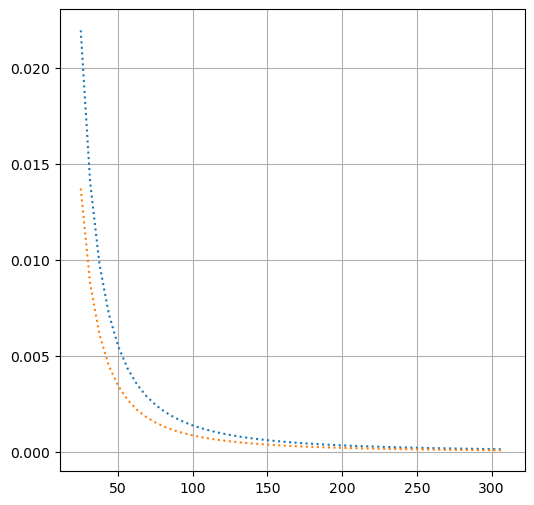

In [18]:
cutoff_ = np.arange(4, 50)*np.pi*2
fig, ax = plt.subplots(figsize=(6,6))

ax.plot(
    cutoff_,
    fit_chelton(cutoff_, 0.4e-2),
    ls=":",
    label="Chelton prediction \n" r"$\sigma_{SSH}$=0.4cm",
)

ax.plot(
    cutoff_,
    fit_chelton(cutoff_, 0.25e-2),
    ls=":",
    label="Chelton prediction \n" r"$\sigma_{SSH}$=0.4cm",
)
ax.grid()

__________________
## Variance and spectra
For isotropic gaussian filter :
$$ Var(\sigma) = \int_{0}^{\inf} E(k)ke^{-\sigma^2k^2}dk $$

For $ E(k) \propto k^{-p} $:

$$ Var(\sigma) \propto \sigma ^{p-2} $$

R-squared: 0.980003
R-squared: 1.000000
p small scale =1.8409380891347535
p large scale =0.5547477828311465
R-squared: 0.980003
R-squared: 1.000000
p small scale =1.8409380891347535
p large scale =0.5547477828311465
R-squared: 0.974079
R-squared: 1.000000
p small scale =1.9369852748167848
p large scale =0.5368418216882525
R-squared: 0.977924
R-squared: 1.000000
p small scale =1.668731754573005
p large scale =-1.1041496197213938


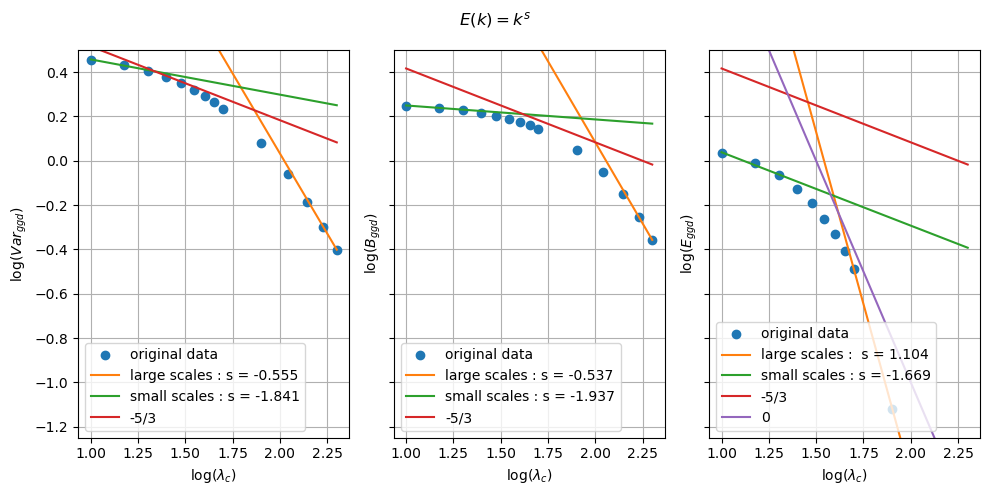

In [199]:
loga = np.log10(dsgf.GGD)
logc = np.log10(dsgf.cutoff)
from scipy import stats
res0 = stats.linregress(logc.sel(cutoff=slice(1, 20)), loga.sel(cutoff=slice(1, 20)))
res1 = stats.linregress(logc.sel(cutoff=slice(160, 200)), loga.sel(cutoff=slice(160, 200)))
print(f"R-squared: {res0.rvalue**2:.6f}")
print(f"R-squared: {res1.rvalue**2:.6f}")

print(f'p small scale ={res0.slope+2}')
print(f'p large scale ={res1.slope+2}')

fig, axs = plt.subplots(1, 3, figsize=(10,5), sharey=True)

# Total variance
ax=axs[0]
loga = np.log10(dsgf.GGD)
logc = np.log10(dsgf.cutoff)
from scipy import stats
res0 = stats.linregress(logc.sel(cutoff=slice(1, 20)), loga.sel(cutoff=slice(1, 20)))
res1 = stats.linregress(logc.sel(cutoff=slice(160, 200)), loga.sel(cutoff=slice(160, 200)))
print(f"R-squared: {res0.rvalue**2:.6f}")
print(f"R-squared: {res1.rvalue**2:.6f}")

print(f'p small scale ={res0.slope+2}')
print(f'p large scale ={res1.slope+2}')
ax.plot(logc, loga, 'o', label='original data')
ax.plot(logc, res1.intercept + res1.slope*logc, label=f'large scales : s = {-round(res1.slope+2, 3)}')
ax.plot(logc, res0.intercept + res0.slope*logc,label=f'small scales : s = {-round(res0.slope+2, 3)}')
ax.plot(logc,0.85+(5/3-2)*logc,label='-5/3')
ax.legend()
ax.grid()
ax.set_ylim(-1.25, 0.5)
ax.set_xlabel(r'log($\lambda_c$)')
ax.set_ylabel(r'log($Var_{ggd}$)')

# B_ggd
ax=axs[1]
loga = np.log10(dsgf.B_ggd)
logc = np.log10(dsgf.cutoff)
from scipy import stats
res0 = stats.linregress(logc.sel(cutoff=slice(1, 20)), loga.sel(cutoff=slice(1, 20)))
res1 = stats.linregress(logc.sel(cutoff=slice(160, 200)), loga.sel(cutoff=slice(160, 200)))
print(f"R-squared: {res0.rvalue**2:.6f}")
print(f"R-squared: {res1.rvalue**2:.6f}")

print(f'p small scale ={res0.slope+2}')
print(f'p large scale ={res1.slope+2}')

ax.plot(logc, loga, 'o', label='original data')
ax.plot(logc, res1.intercept + res1.slope*logc,  label=f'large scales : s = {-round(res1.slope+2, 3)}')
ax.plot(logc, res0.intercept + res0.slope*logc, label=f'small scales : s = {-round(res0.slope+2, 3)}')
ax.plot(logc,0.75+(5/3-2)*logc,label='-5/3')
ax.grid()
ax.legend()
ax.set_xlabel(r'log($\lambda_c$)')
ax.set_ylabel(r'log($B_{ggd}$)')


# E_ggd
ax=axs[2]
loga = np.log10(dsgf.E_ggd)
logc = np.log10(dsgf.cutoff)
from scipy import stats
res0 = stats.linregress(logc.sel(cutoff=slice(1, 20)), loga.sel(cutoff=slice(1, 20)))
res1 = stats.linregress(logc.sel(cutoff=slice(50, 81)), loga.sel(cutoff=slice(50, 81)))
print(f"R-squared: {res0.rvalue**2:.6f}")
print(f"R-squared: {res1.rvalue**2:.6f}")

print(f'p small scale ={res0.slope+2}')
print(f'p large scale ={res1.slope+2}')

ax.plot(logc, loga, 'o', label='original data')
ax.plot(logc, res1.intercept + res1.slope*logc,  label=f'large scales :  s = {-round(res1.slope+2, 3)}')
ax.plot(logc, res0.intercept + res0.slope*logc, label=f'small scales : s = {-round(res0.slope+2, 3)}')
ax.plot(logc,0.75+(5/3-2)*logc,label='-5/3')
ax.plot(logc,3+(-2)*logc,label='0')
ax.grid()
ax.legend()
ax.set_xlabel(r'log($\lambda_c$)')
ax.set_ylabel(r'log($E_{ggd}$)')

fig.suptitle(r'$E(k) = k^{s}$')
fig.tight_layout()

In [198]:
loga

<xarray.DataArray 'E_ggd' (cutoff: 15)> Size: 120B
array([ 0.07446292,  0.03496467, -0.01112822, -0.06622692, -0.12716799,
       -0.1921969 , -0.26065664, -0.3325344 , -0.40811447, -0.48787066,
       -1.12148963,         nan,         nan,         nan,         nan])
Coordinates:
    id_comb  <U10 40B 'filtered'
  * cutoff   (cutoff) float64 120B 0.0 10.0 15.0 20.0 ... 140.0 170.0 200.0

But better fit for :
$$ Var(\sigma) \propto e^{-\sigma/\sigma_c}$$

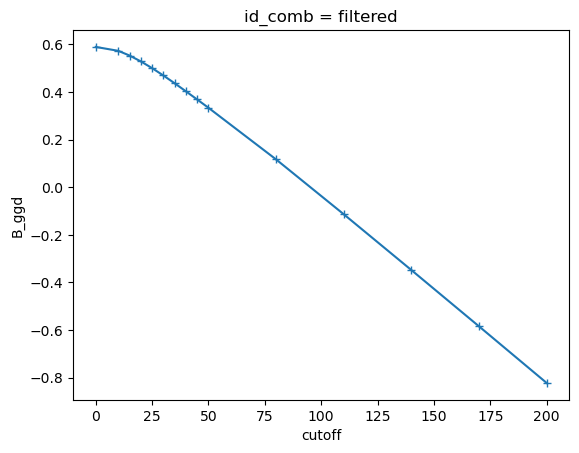

In [24]:
fig, ax = plt.subplots()
np.log(dsgf.B_ggd).plot(ax=ax, label="L3-2km filtered", marker="+")

# Gaussian
## Observed

/dev/shm/pbs.5317606.datarmor0/ipykernel_49408/2800794696.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(a)
/dev/shm/pbs.5317606.datarmor0/ipykernel_49408/2800794696.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(a)


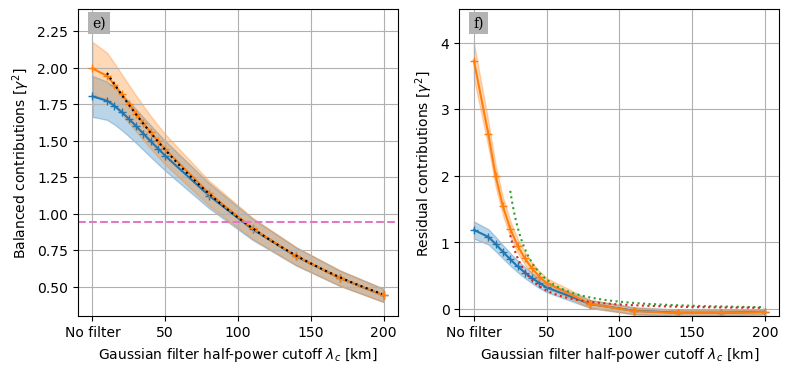

In [191]:
xlim = 200
from matplotlib.gridspec import GridSpec

fig, axs = plt.subplots(1, 2, frameon=False, figsize=(8, 4))

ax = axs[0]
dsgf.B_ggd.plot(ax=ax, label="L3-2km filtered", marker="+")
plot_error(dsgf, "cutoff", "B_ggd", ax=ax, suf="er__", color="tab:blue", alpha=0.3)
dsgc.B_ggd.plot(ax=ax, label="L3-2km calibrated", marker="+")
plot_error(dsgc, "cutoff", "B_ggd", ax=ax, suf="er__", color="tab:orange", alpha=0.3)
b_exp_fit.plot(
    ax=ax,
    ls=":",
    color="k",
    label=rf"{round(b_exp_popt[0])} exp(-$\lambda_c$/{round(b_exp_popt[1])})",
)

ax.axhline(
    ds4.sel(altiprod="L4-SWOT-nadir").B_ggd,
    ls="--",
    color="tab:pink",
    label="L4-SWOT nadir",
)
put_fig_letter(fig, ax, "e")
ax.set_ylabel(r"Balanced contributions [$\gamma^2$]")
ax.set_ylim(0.3, 2.4)

ax = axs[1]
dsgf.E_ggd.plot(
    ax=ax,
    marker="+",
    label="L3-2km filtered",
)
plot_error(dsgf, "cutoff", "E_ggd", ax=ax, suf="er__", color="tab:blue", alpha=0.3)
dsgc.E_ggd.plot(
    ax=ax,
    marker="+",
    label="L3-2km calibrated",
)
plot_error(dsgc, "cutoff", "E_ggd", ax=ax, suf="er__", color="tab:orange", alpha=0.3)

cutoff_ = np.arange(25, 200)
f37 = 2 * 2 * np.pi / 86164.1 * np.sin(37 * np.pi / 180)
ax.plot(
    cutoff_,
    fit_chelton(cutoff_ , 0.4e-2)*f37**2/U2,
    ls=":",
    label="Chelton prediction \n" r"$\sigma_{SSH}$=0.4cm",
)
# ax.plot(np.arange(1,50), fit_chelton(np.arange(1,50)*1e3, 0.4e-2)/U2, ls=':', label ='Chelton 2024 $\sigma_{SSH}$=0.4cm')
ax.plot(
    cutoff_,
    fit_chelton(cutoff_, 0.25e-2)*f37**2 / U2,
    ls=":",
    label="Chelton prediction\n" + r"$\sigma_{SSH}$=0.25cm",
)


put_fig_letter(fig, ax, "f")

ax.set_ylabel(r"Residual contributions [$\gamma^2$]")
ax.set_ylim(-0.1, 4.5)

fig.tight_layout()

for ax in axs:
    xticks = ax.get_xticks().tolist()
    a = [int(a_) for a_ in xticks]
    a[1] = "No filter"
    ax.set_xticklabels(a)
    ax.set_xlabel(r"Gaussian filter half-power cutoff $\lambda_c$ [km]")
    ax.grid()
    # ax.legend()
    ax.set_title("")

#ax.set_title("Focus on the pressure gradient term")
# ins_ax_box = [0.4, 0.30, 0.58, 0.4]
# ins = axs[1].inset_axes(ins_ax_box)
# rc = (dsgf.E_ggd/(dsgf.B_ggd -ds4.sel(altiprod='L4-SWOT-nadir').B_ggd).values)
# rf = (dsgc.E_ggd/(dsgc.B_ggd -ds4.sel(altiprod='L4-SWOT-nadir').B_ggd).values)
# rc.plot(ax=ins, label = 'L3-2km calibrated', marker='+')
# rf.plot(ax=ins, label = 'L3-2km calibrated', marker='+')
# ins.set_xlim(0,14)
# ins.set_ylim(0,5)
# ins.set_title('')
# ins.grid()
# a=ins.get_xticks().tolist()
# a = [int(a_) for a_ in a]
# a[0]='No filter'
# ins.set_xticklabels(a)
# ins.set_xlabel(r'Gaussian filter cutoff $\lambda_c$ [km]')
# put_fig_letter(fig, ins, 'c')
# ins.set_ylabel(r'$R_{N/A}$')

/dev/shm/pbs.5204485.datarmor0/ipykernel_8408/529933638.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(a)
/dev/shm/pbs.5204485.datarmor0/ipykernel_8408/529933638.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(a)


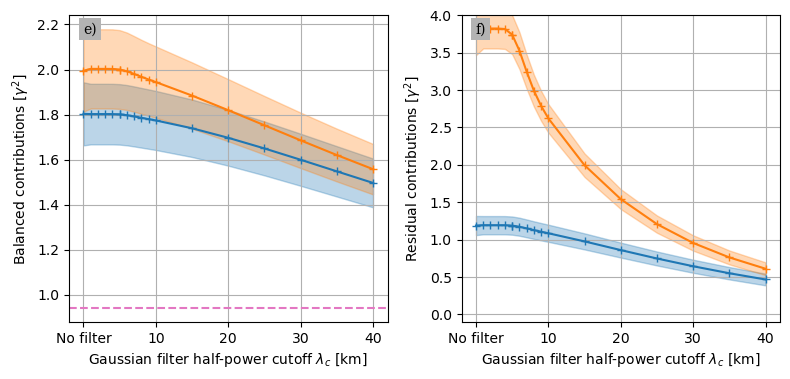

In [83]:
xlim = 40
dsgf_ = dsgf.sel(cutoff=slice(0,xlim))
dsgc_ = dsgc.sel(cutoff=slice(0,xlim))
from matplotlib.gridspec import GridSpec

fig, axs = plt.subplots(1, 2, frameon=False, figsize=(8, 4))

ax = axs[0]
dsgf_.B_ggd.plot(ax=ax, label="L3-2km filtered", marker="+")
plot_error(dsgf_, "cutoff", "B_ggd", ax=ax, suf="er__", color="tab:blue", alpha=0.3)
dsgc_.B_ggd.plot(ax=ax, label="L3-2km calibrated", marker="+")
plot_error(dsgc_, "cutoff", "B_ggd", ax=ax, suf="er__", color="tab:orange", alpha=0.3)

ax.axhline(
    ds4.sel(altiprod="L4-SWOT-nadir").B_ggd,
    ls="--",
    color="tab:pink",
    label="L4-SWOT nadir",
)
put_fig_letter(fig, ax, "e")
ax.set_ylabel(r"Balanced contributions [$\gamma^2$]")


ax = axs[1]
dsgf_.E_ggd.plot(
    ax=ax,
    marker="+",
    label="L3-2km filtered",
)
plot_error(dsgf_, "cutoff", "E_ggd", ax=ax, suf="er__", color="tab:blue", alpha=0.3)
dsgc_.E_ggd.plot(
    ax=ax,
    marker="+",
    label="L3-2km calibrated",
)
plot_error(dsgc_, "cutoff", "E_ggd", ax=ax, suf="er__", color="tab:orange", alpha=0.3)

put_fig_letter(fig, ax, "f")

ax.set_ylabel(r"Residual contributions [$\gamma^2$]")
ax.set_ylim(-0.1, 4)

fig.tight_layout()

for ax in axs:
    a = ax.get_xticks().tolist()
    a = [int(a_) for a_ in a]
    a[1] = "No filter"
    ax.set_xticklabels(a)
    ax.set_xlabel(r"Gaussian filter half-power cutoff $\lambda_c$ [km]")
    ax.grid()
    # ax.legend()
    ax.set_title("")

/dev/shm/pbs.5204485.datarmor0/ipykernel_8408/1628810742.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(a)
/dev/shm/pbs.5204485.datarmor0/ipykernel_8408/1628810742.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(a)


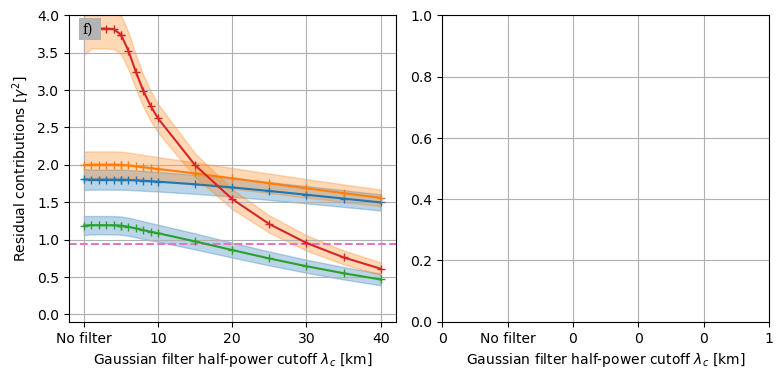

In [84]:
xlim = 40
dsgf_ = dsgf.sel(cutoff=slice(0,xlim))
dsgc_ = dsgc.sel(cutoff=slice(0,xlim))
from matplotlib.gridspec import GridSpec

fig, axs = plt.subplots(1, 2, frameon=False, figsize=(8, 4))

ax = axs[0]
dsgf_.B_ggd.plot(ax=ax, label="L3-2km filtered", marker="+")
plot_error(dsgf_, "cutoff", "B_ggd", ax=ax, suf="er__", color="tab:blue", alpha=0.3)
dsgc_.B_ggd.plot(ax=ax, label="L3-2km calibrated", marker="+")
plot_error(dsgc_, "cutoff", "B_ggd", ax=ax, suf="er__", color="tab:orange", alpha=0.3)

ax.axhline(
    ds4.sel(altiprod="L4-SWOT-nadir").B_ggd,
    ls="--",
    color="tab:pink",
    label="L4-SWOT nadir",
)
put_fig_letter(fig, ax, "e")
ax.set_ylabel(r"Balanced contributions [$\gamma^2$]")


ax = axs[0]
dsgf_.E_ggd.plot(
    ax=ax,
    marker="+",
    label="L3-2km filtered",
)
plot_error(dsgf_, "cutoff", "E_ggd", ax=ax, suf="er__", color="tab:blue", alpha=0.3)
dsgc_.E_ggd.plot(
    ax=ax,
    marker="+",
    label="L3-2km calibrated",
)
plot_error(dsgc_, "cutoff", "E_ggd", ax=ax, suf="er__", color="tab:orange", alpha=0.3)

put_fig_letter(fig, ax, "f")

ax.set_ylabel(r"Residual contributions [$\gamma^2$]")
ax.set_ylim(-0.1, 4)

fig.tight_layout()

for ax in axs:
    a = ax.get_xticks().tolist()
    a = [int(a_) for a_ in a]
    a[1] = "No filter"
    ax.set_xticklabels(a)
    ax.set_xlabel(r"Gaussian filter half-power cutoff $\lambda_c$ [km]")
    ax.grid()
    # ax.legend()
    ax.set_title("")

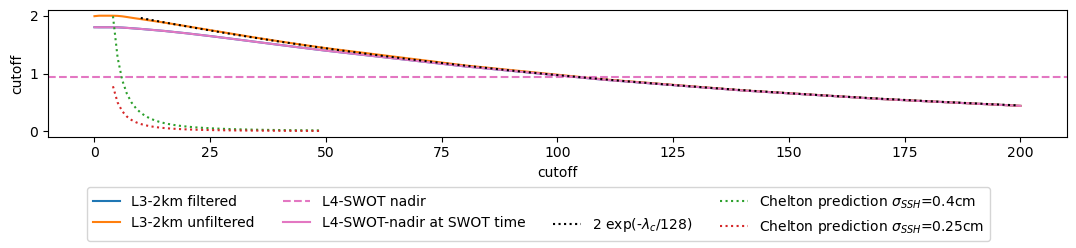

In [86]:
fig, ax = plt.subplots(1, 1, frameon=False, figsize=(11, 2.5))
dsgf.B_ggd.plot(ax=ax, label="L3-2km filtered")
dsgc.B_ggd.plot(ax=ax, label="L3-2km unfiltered")
ax.axhline(
    ds4.sel(altiprod="L4-SWOT-nadir").B_ggd,
    ls="--",
    color="tab:pink",
    label="L4-SWOT nadir",
)
dsgf.B_ggd.plot(ax=ax, label="L4-SWOT-nadir at SWOT time", color="tab:pink")
dsgc.B_ggd.plot(ax=ax, label=" ", ls="")
b_exp_fit.plot(
    ax=ax,
    ls=":",
    color="k",
    label=rf"{round(b_exp_popt[0])} exp(-$\lambda_c$/{round(b_exp_popt[1])})",
)
ax.plot(
    np.arange(4, 50),
    theoritical_chelton(np.arange(4, 50) * 1e3, 0.4e-2) / U2,
    ls=":",
    label="Chelton prediction $\sigma_{SSH}$=0.4cm",
    color="tab:green",
)
# ax.plot(np.arange(1,50), fit_chelton(np.arange(1,50)*1e3, 0.4e-2)/U2, ls=':', label ='Chelton 2024 $\sigma_{SSH}$=0.4cm')
ax.plot(
    np.arange(4, 50),
    theoritical_chelton(np.arange(4, 50) * 1e3, 0.25e-2) / U2,
    ls=":",
    label="Chelton prediction $\sigma_{SSH}$=0.25cm",
    color="tab:red",
)

fig.legend(ncol=4, loc="lower center")


fig.tight_layout(rect=[0, 0.2, 1, 1])

In [87]:
((dsgc.sel(cutoff=0) - dsgc) / dsgc.sel(cutoff=0)).E_ggd.to_dataframe()

,id_comb,E_ggd
cutoff,,
0.0,calibrated,0.000000
1.0,calibrated,-0.024986
2.0,calibrated,-0.025002
3.0,calibrated,-0.024997
4.0,calibrated,-0.023237
5.0,calibrated,-0.002975
5.0,calibrated,-0.002975
6.0,calibrated,0.054226
7.0,calibrated,0.129718


In [88]:
(((dsgf.sel(cutoff=0) - dsgf) / dsgf.sel(cutoff=0)).E_ggd).to_dataframe()

,id_comb,E_ggd
cutoff,,
0.0,filtered,0.000000
1.0,filtered,-0.003892
2.0,filtered,-0.003899
3.0,filtered,-0.003899
4.0,filtered,-0.003536
5.0,filtered,0.000701
5.0,filtered,0.000701
6.0,filtered,0.013347
7.0,filtered,0.031935


In [93]:
dsgc.sel(cutoff=15)[["B_ggd", "E_ggd", "er__B_ggd", "er__E_ggd"]]

<xarray.Dataset> Size: 80B
Dimensions:    ()
Coordinates:
    id_comb    <U10 40B 'calibrated'
    cutoff     float64 8B 15.0
Data variables:
    B_ggd      float64 8B 1.884
    E_ggd      float64 8B 1.994
    er__B_ggd  float64 8B 0.1473
    er__E_ggd  float64 8B 0.157
Attributes:
    error_method:  centrallimit

In [95]:
dsgf.sel(cutoff=0)[["B_ggd", "E_ggd", "er__B_ggd", "er__E_ggd"]]

<xarray.Dataset> Size: 80B
Dimensions:    ()
Coordinates:
    id_comb    <U10 40B 'filtered'
    cutoff     float64 8B 0.0
Data variables:
    B_ggd      float64 8B 1.803
    E_ggd      float64 8B 1.187
    er__B_ggd  float64 8B 0.1401
    er__E_ggd  float64 8B 0.1281
Attributes:
    error_method:  centrallimit

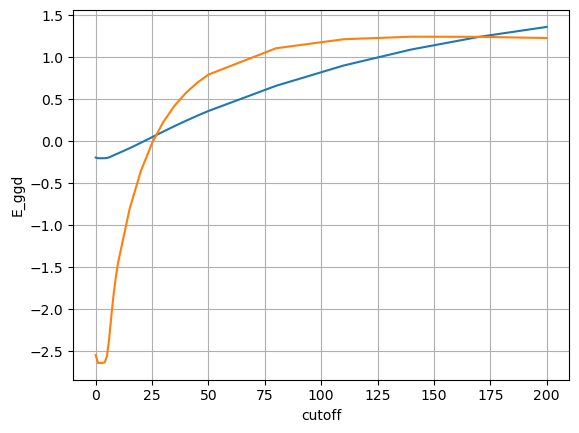

In [108]:
a = (dsgf.sel(cutoff=0)[["B_ggd", "E_ggd"]] - dsgc[["B_ggd", "E_ggd"]])
a.B_ggd.plot()
a.E_ggd.plot()
plt.grid()

In [110]:
 (dsgf.sel(cutoff=0)[["B_ggd", "E_ggd"]] - dsgc.sel(cutoff=25)[["B_ggd", "E_ggd"]])

<xarray.Dataset> Size: 16B
Dimensions:  ()
Data variables:
    B_ggd    float64 8B 0.05081
    E_ggd    float64 8B -0.01906

In [111]:
(
    dsgf.sel(cutoff=0)[["er__B_ggd", "er__E_ggd"]]
    + dsgc.sel(cutoff=25)[["er__B_ggd", "er__E_ggd"]]
)

<xarray.Dataset> Size: 16B
Dimensions:    ()
Data variables:
    er__B_ggd  float64 8B 0.2701
    er__E_ggd  float64 8B 0.2437

/dev/shm/pbs.5204485.datarmor0/ipykernel_8408/2862296358.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(a)


Text(0.5, 1.0, '')

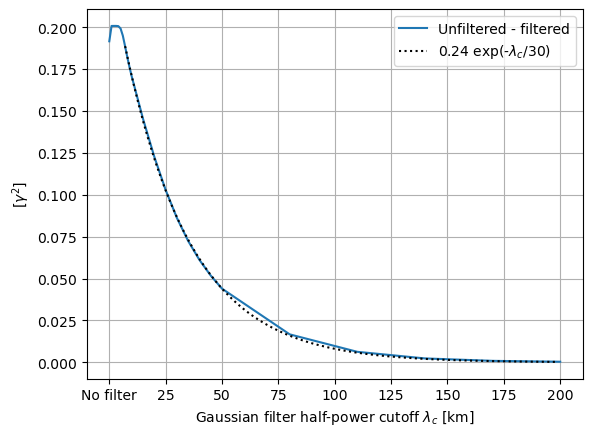

In [135]:
diffB = (dsgc.B_ggd - dsgf.B_ggd)

cutoff = xr.DataArray(data=np.arange(7, 200), dims=["cutoff"], name="cutoff")
b_exp_popt0, b_pcov0 = curve_fit(exp_fit, diffB.sel(cutoff=slice(7, 200)).cutoff, diffB.sel(cutoff=slice(7, 200)))
b_exp_fit0 = xr.DataArray(exp_fit(cutoff, *b_exp_popt0), coords={"cutoff": cutoff})
b_exp_popt0[1] = b_exp_popt0[1]*2*np.pi

fig, ax= plt.subplots()
diffB.plot(ax=ax, label = 'Unfiltered - filtered')
b_exp_fit0.plot(ax=ax, label=rf"{round(b_exp_popt0[0], 2)} exp(-$\lambda_c$/{round(b_exp_popt0[1])})",ls=':', color='k')

a = ax.get_xticks().tolist()
a = [int(a_) for a_ in a]
a[1] = "No filter"
ax.set_xticklabels(a)
ax.set_xlabel(r"Gaussian filter half-power cutoff $\lambda_c$ [km]")
ax.grid()
ax.set_title('Difference between unfiltered and filtered \n Pressure gradient balanced contributions')
ax.set_ylabel(r'[$\gamma^2$]')
ax.legend()
ax.set_title("")
    

In [23]:
dsgf.sel(cutoff=0)[["B_ggd", "E_ggd"]] - dsgc.sel(cutoff=4)[["B_ggd", "E_ggd"]]

<xarray.Dataset> Size: 16B
Dimensions:  ()
Data variables:
    B_ggd    float64 8B 0.05259
    E_ggd    float64 8B -0.01146

In [24]:
dsgc.sel(cutoff=6)[["B_ggd", "E_ggd"]]

<xarray.Dataset> Size: 64B
Dimensions:  ()
Coordinates:
    id_comb  <U10 40B 'calibrated'
    cutoff   float64 8B 6.0
Data variables:
    B_ggd    float64 8B 1.586
    E_ggd    float64 8B 0.6743
Attributes:
    error_method:  centrallimit

In [25]:
dsgc

<xarray.Dataset> Size: 18kB
Dimensions:           (cutoff: 17)
Coordinates:
    id_comb           <U10 40B 'calibrated'
  * cutoff            (cutoff) float64 136B 0.0 4.0 6.0 8.0 ... 45.0 50.0 55.0
Data variables: (12/132)
    ACCn              (cutoff) float64 136B 1.811 1.801 1.801 ... 1.801 1.801
    CORn              (cutoff) float64 136B 3.261 3.241 3.241 ... 3.241 3.241
    GGDn              (cutoff) float64 136B 3.193 1.751 1.397 ... 0.09521 0.0778
    WDn               (cutoff) float64 136B 0.08161 0.08079 ... 0.08079 0.08079
    Sn                (cutoff) float64 136B 2.78 1.548 1.36 ... 1.863 1.896
    ACCe              (cutoff) float64 136B 1.726 1.721 1.721 ... 1.721 1.721
    ...                ...
    er__X_acc_wd      (cutoff) float64 136B 0.0916 0.08916 ... 0.08916 0.08916
    er__X_cor_ggd     (cutoff) float64 136B 0.4551 0.3133 ... 0.07125 0.06517
    er__X_cor_wd      (cutoff) float64 136B 0.2319 0.2236 ... 0.2236 0.2236
    er__X_ggd_wd      (cutoff) float64 136B 0.1145 0.06568 ... 0.01638 0.01603
    er__D_cyclo       (cutoff) float64 136B 0.3839 0.2691 ... 0.05966 0.05428
    er__D_anticyclo   (cutoff) float64 136B 0.6834 0.5703 ... 0.4589 0.4571
Attributes:
    error_method:  centrallimit

In [26]:
def plot_error(df, x, v, ax, suf="er__", color="silver", alpha=1):
    ax.fill_between(
        df[x], df[v] - df[suf + v], df[v] + df[suf + v], color=color, alpha=alpha
    )

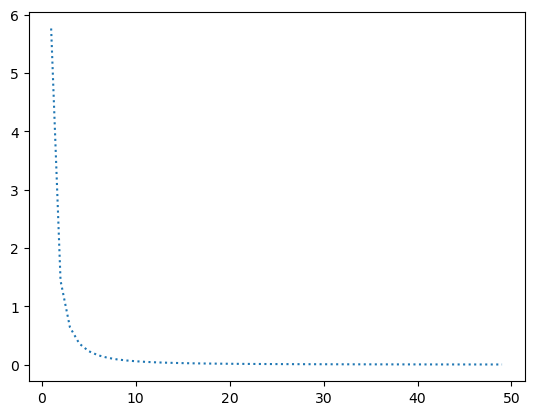

In [27]:
plt.plot(
    np.arange(1, 50),
    fit_chelton(np.arange(1, 50) * 1e3, 0.4e-2) / U2,
    ls=":",
    label="Chelton 2024 $\sigma_{SSH}$=0.4cm",
)

KeyError: "not all values found in index 'altiprod'. Try setting the `method` keyword argument (example: method='nearest')."

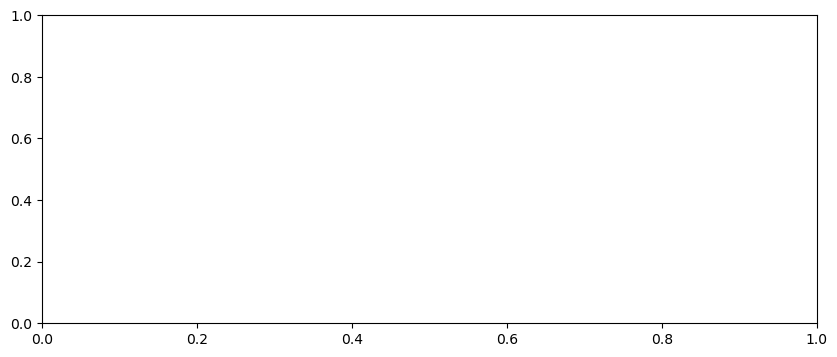

In [28]:
from matplotlib.gridspec import GridSpec

fig, ax = plt.subplots(1, 1, frameon=False, figsize=(10, 4))
rc = dsgc.E_ggd / (dsgc.B_ggd - ds4.sel(altiprod="L4_withnadirswot").B_ggd).values
rf = dsgf.E_ggd / (dsgf.B_ggd - ds4.sel(altiprod="L4_withnadirswot").B_ggd).values

rc.plot(ax=ax, label="L3-2km calibrated", marker="+")
rf.plot(ax=ax, label="L3-2km calibrated", marker="+")
ax.set_xlim(0, 14)
ax.set_ylabel(r"Residual contribution over the difference with L4")
ax.grid()
a = ax.get_xticks().tolist()
a = [int(a_) for a_ in a]
a[0] = "No filter"
ax.set_xticklabels(a)
ax.set_xlabel(r"Gaussian filter cutoff $\lambda_c$ [km]")
ax.set_ylim(0, 6)
ax.set_title("")

In [ ]:
a

In [ ]:
# Exponential fit
b_exp_fit.plot(
    ax=ax,
    ls=":",
    color="b",
    label=rf"{round(b_exp_popt[0])} exp(-$\lambda_c$/{round(b_exp_popt[1])})",
)
ig.plot(ax=ax, ls=":", color="k", label=rf"$\lambda^{-2}$ fit")
# best fit but not exponenetial
# e_fit.sel(cutoff = slice(5, 55)).plot(ax=ax, ls=':',color = 'k', label = rf'{round(e_popt[0])} exp(-$\lambda_c$/{round(e_popt[1])}) - {round(e_popt[2])}/$\lambda_c^{round(e_popt[3])}$')

ax.scatter(0, ds4.isel(altiprod=0).B_ggd, marker="*", c=c0["ggd"])
ax.scatter(0, ds4.isel(altiprod=0).E_ggd, marker="*", c="grey")
# dsg.GGD.plot(ax=ax, label = 'MS')

for ap in ds4.altiprod.values[3:4]:
    ax.axhline(
        ds4.sel(altiprod=ap).B_ggd,
        ls="--",
        color=c0["ggd"],
        label=ap + " Balanced contribution",
    )
    # ax.annotate(ap, (40,ds4.sel(altiprod=ap).B_ggd+0.02))
    # ax.axhline(ds4.sel(altiprod=ap.values).E_ggd, ls=':', color='orange')

    # ax.axhline(ds4.sel(altiprod=ap.values).GGD, ls=':', label=ap.values, color='orange')

ax.set_xlim(-1, 57)

a = ax.get_xticks().tolist()
a = [int(a_) for a_ in a]
a[1] = "No filter"

ax.set_xticklabels(a)
ax.set_xlabel(r"Gaussian filter cutoff $\lambda_c$ [km]")
ax.grid()
ax.legend()
ax.set_ylabel(r"[$\gamma^2$]")
ax.set_ylim(-0.5, 4)

In [ ]:
fig, ax = plt.subplots(1, 1)
# ax = axs[0]
abs(dsg.B_ggd / dsg.E_ggd).plot(ax=ax, label="Balanced/Residual contribution")
ax.grid()
ax.legend()
ax.set_ylabel(r"[$\gamma^2$]")

# Theoritical -> not the good model 

In [29]:
dsms = xr.open_dataset(os.path.join(zarr_dir, "diag_files", "ms_noise_gaussian.nc"))
dsms["cutoff"] = dsms["cutoff"] / 1000

FileNotFoundError: [Errno 2] No such file or directory: '/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/diag_files/ms_noise_gaussian.nc'

Text(0, 0.5, '[$\\gamma^2$]')

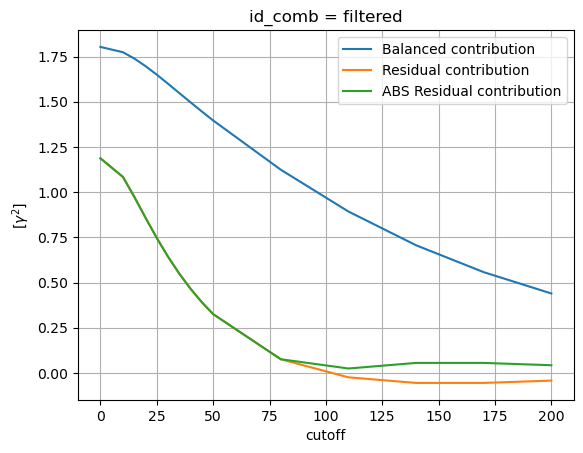

In [182]:
fig, ax = plt.subplots(1, 1)
# ax = axs[0]
dsgf.B_ggd.plot(ax=ax, label="Balanced contribution")
dsgf.E_ggd.plot(ax=ax, label="Residual contribution")
abs(dsgf.E_ggd).plot(ax=ax, label="ABS Residual contribution")
#dsms.ms_noise_ggd.plot(hue="sigmassh", ax=ax)
# dsg.GGD.plot(ax=ax, label = 'MS')
# ax.plot(ct, varggd_from_sigmassh(sigmassh(ct, sig3km=sig3km1)), ls='--', label = 'sig3km = 0.4 cm')
# ax.plot(ct, varggd_from_sigmassh(sigmassh(ct, sig3km=sig3km2)), ls='--', label = 'sig3km = 0.25 cm')
# e_fit.plot(ls=':', label = rf'{np.round(e_popt[0])}exp(-{np.round(e_popt[1], 2)}$\lambda_c$) - {np.round(e_popt[2], 2)}/$\lambda_c$^{np.round(e_popt[3], 2)}')
# b_fit.plot(ls=':')
# b_exp_fit.plot(ls=':', label = rf'{np.round(b_exp_popt[0])}exp(-{np.round(b_exp_popt[1], 2)}$\lambda_c$)')
# g_exp_fit.plot(ls=':', label = rf'{np.round(g_exp_popt[0])}exp(-{np.round(g_exp_popt[1], 4)}*$\lambda_c$)')

ax.grid()
ax.legend()
ax.set_ylabel(r"[$\gamma^2$]")

## Other quantities

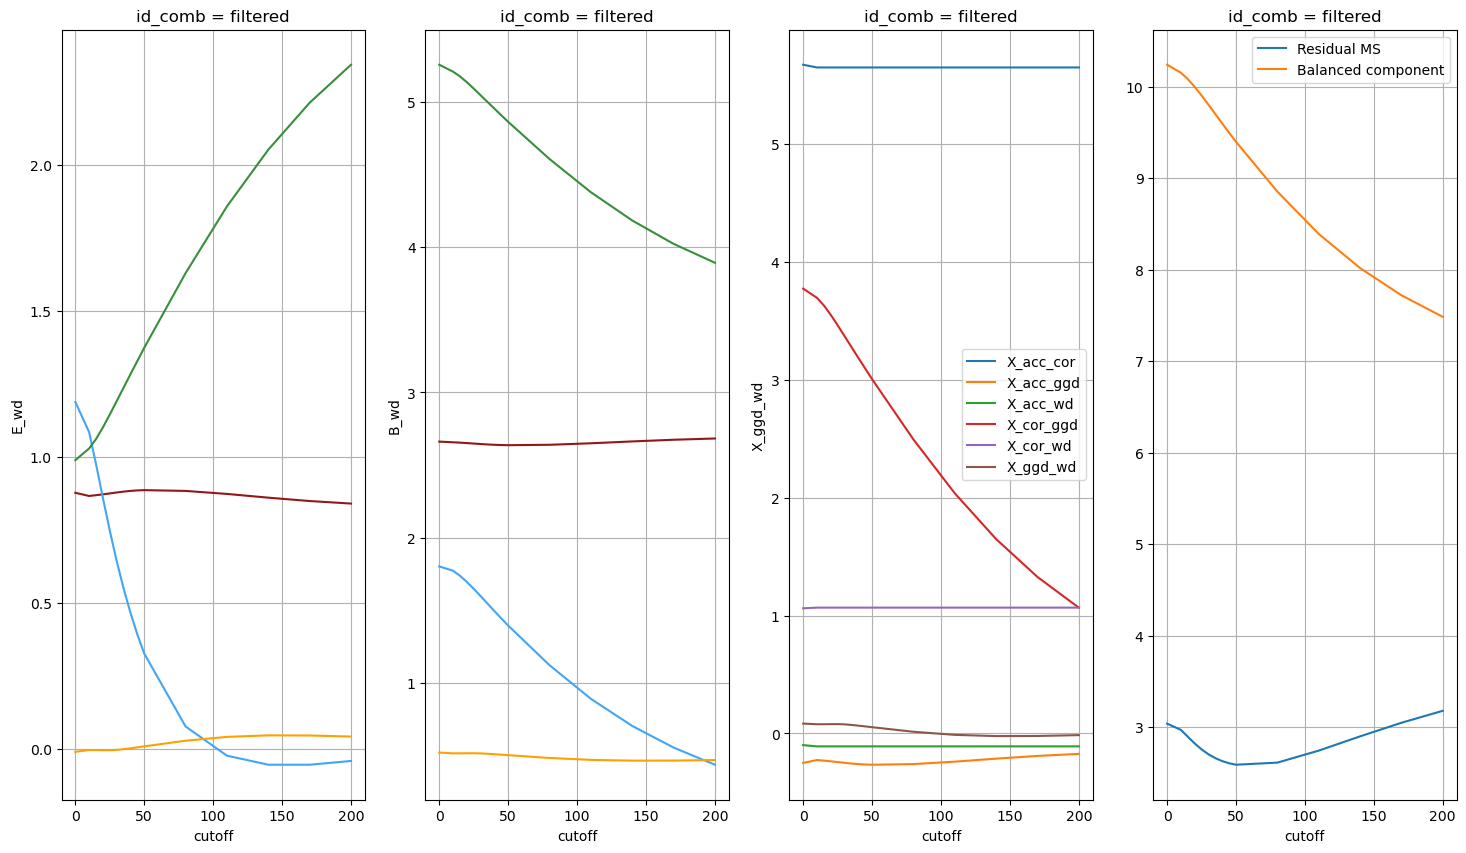

In [184]:
dsg=dsgf
fig, axs = plt.subplots(1, 4, figsize=(18, 10))
ax = axs[0]
for v in ["acc", "ggd", "cor", "wd"]:
    dsg["E_" + v].plot(color=c0[v], ax=ax)
ax = axs[1]
for v in ["acc", "ggd", "cor", "wd"]:
    dsg["B_" + v].plot(color=c0[v], ax=ax)
ax = axs[2]
for v in [v for v in dsg if ("X_" in v) & ("er__" not in v)]:
    dsg[v].plot(label=v, ax=ax)
    ax.legend()

ax = axs[3]
dsg.S.plot(ax=ax, label="Residual MS")
(sum([dsg["B_" + v] for v in ["acc", "ggd", "cor", "wd"]])).plot(
    ax=ax, label="Balanced component"
)
ax.legend()

for ax in axs:
    ax.grid()

# Fitting kernel - Not working

In [5]:
# FITTING KERNEL
npts = np.arange(5, 19, 2)

# SURFACE
base_dic = dict(
    dt="12h",
    drifter_preprocess=drifter_preprocess,
    drifter_preprocess_param=drifter_preprocess_param,
    alti_product_key=alti_product_key,
    alti_diff_method="fitting_kernel",
    alti_diff_method_param="",
    ggd_var="etaf",
    wd_product_key="era5",
    wd_model="rio",
    wd_depth="0",
)

comb_list = [
    update_dict(base_dic, dict(alti_diff_method_param=int(npt))) for npt in npts
]

ds0 = dataset_coloc_combs(comb_list, nearest=False, remove_id_outliers=True)
ds0["comb"] = ds0["id_comb"]
ds0["id_comb"] = ("id_comb", npts)
distance_to_coast = ds0.distance_to_coast.isel(id_comb=0)
ds0["distance_to_coast"] = ("row_number", distance_to_coast.values)

# DEPTH 15M
base_dic = update_dict(base_dic, dict(wd_depth="15"))
comb_list = [
    update_dict(base_dic, dict(alti_diff_method_param=int(npt))) for npt in npts
]

ds15 = dataset_coloc_combs(comb_list, nearest=False, remove_id_outliers=True)
ds15["comb"] = ds15["id_comb"]
ds15["id_comb"] = ("id_comb", npts)
distance_to_coast = ds15.distance_to_coast.isel(id_comb=0)
ds15["distance_to_coast"] = ("row_number", distance_to_coast.values)

DS = xr.concat(
    [ds0.where(ds0.depth == 0, drop=True), ds15.where(ds15.depth == 15, drop=True)],
    dim="row_number",
)
DS = DS.where(DS.time_to_swot / pd.Timedelta("1h") < dt).dropna("row_number")
DS = DS.where((abs(DS.ggde) < max_ggd) & (abs(DS.ggdn) < max_ggd), drop=True)
DSF = DS.where(DS.distance_to_coast > distance_to_coast_max, drop=True)


DSF = DSF.rename({"id_comb": "npts"})
DSF["npts"] = DSF.npts
DSF["npts"] = DSF["npts"].assign_attrs(
    {"long_name": "Fitting kernel number of points", "units": "npts"}
)


# Closure figs
dsf = compute_mean_square(DSF) / U2

289188
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_5_etaf__era5_rio0
276889
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_7_etaf__era5_rio0
264246
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_9_etaf__era5_rio0
250794
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_11_etaf__era5_rio0
237840
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_13_etaf__era5_rio0
223946
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_15_etaf__era5_rio0
210192
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_17_etaf__era5_rio0
Identified SWOT and drifter outliers have been removed
289188
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_5_etaf__era5_rio15
276889
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_7_etaf__era5_rio15
264246
12h_spectral_decomp_all_med_vari

Text(0, 0.5, '[$\\gamma^2$]')

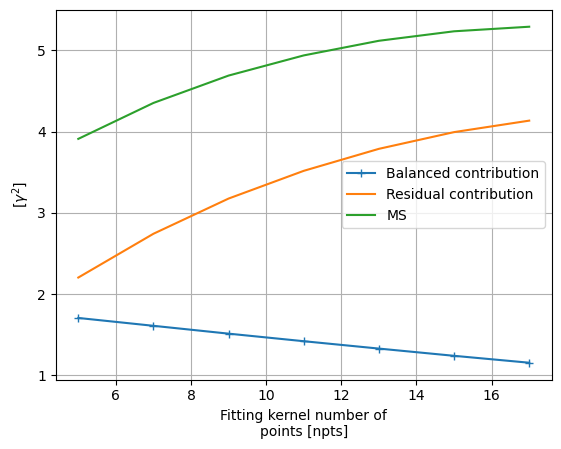

In [6]:
fig, ax = plt.subplots(1, 1)
# ax = axs[0]
dsf.B_ggd.plot(ax=ax, label="Balanced contribution", marker="+")
dsf.E_ggd.plot(ax=ax, label="Residual contribution")
dsf.GGD.plot(ax=ax, label="MS")

ax.grid()
ax.legend()
ax.set_ylabel(r"[$\gamma^2$]")